In [1]:
import pandas as pd

sales_data = {
    "order_id": [1001, 1002, 1003, 1004, 1005],
    "product": ["Laptop", "Mouse", "Keyboard", "Laptop", "Monitor"],
    "quantity": [2, 3, 1, 1, 2],
    "price": [50000, 500, 1500, 50000, 12000]
}

df = pd.DataFrame(sales_data)

df

,order_id,product,quantity,price
0,1001,Laptop,2,50000
1,1002,Mouse,3,500
2,1003,Keyboard,1,1500
3,1004,Laptop,1,50000
4,1005,Monitor,2,12000


In [2]:
df.to_csv("sales.csv", index=False)

print("CSV Created")

CSV Created


In [3]:
import pandas as pd

raw_df = pd.read_csv("sales.csv")

print("Rows Extracted:", len(raw_df))

raw_df.head()

Rows Extracted: 5


,order_id,product,quantity,price
0,1001,Laptop,2,50000
1,1002,Mouse,3,500
2,1003,Keyboard,1,1500
3,1004,Laptop,1,50000
4,1005,Monitor,2,12000


In [4]:
clean_df = raw_df.copy()

clean_df.drop_duplicates(inplace=True)

clean_df["revenue"] = (
    clean_df["quantity"] *
    clean_df["price"]
)

clean_df

,order_id,product,quantity,price,revenue
0,1001,Laptop,2,50000,100000
1,1002,Mouse,3,500,1500
2,1003,Keyboard,1,1500,1500
3,1004,Laptop,1,50000,50000
4,1005,Monitor,2,12000,24000


In [5]:
assert clean_df["order_id"].isnull().sum() == 0

assert (clean_df["quantity"] > 0).all()

print("Data Quality Checks Passed")

Data Quality Checks Passed


In [6]:
clean_df.to_csv(
    "sales_processed.csv",
    index=False
)

print("Data Loaded")

Data Loaded


In [9]:
clean_df["revenue"].sum()



,revenue
product,
Laptop,150000
Monitor,24000
Keyboard,1500
Mouse,1500


In [11]:
clean_df.groupby(
    "product"
)["revenue"].sum()

,revenue
product,
Keyboard,1500
Laptop,150000
Monitor,24000
Mouse,1500


In [10]:
clean_df.groupby(
    "product"
)["revenue"].sum().sort_values(
    ascending=False
)

,revenue
product,
Laptop,150000
Monitor,24000
Keyboard,1500
Mouse,1500


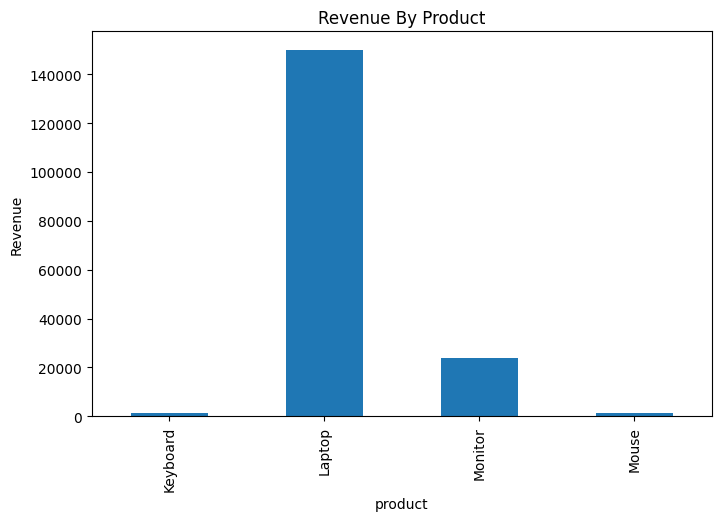

In [12]:
import matplotlib.pyplot as plt

revenue_by_product = (
    clean_df.groupby("product")
    ["revenue"]
    .sum()
)

revenue_by_product.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue By Product")
plt.ylabel("Revenue")
plt.show()

In [13]:
from google.colab import files

files.download("sales_processed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>